In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки copy
import copy

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения плотностей распределений:
# 1. порождающего источника (Zn)
# 2. фиктивного источника (Zim)
# 3. случайной величины с ограниченной справа
#    областью рассеяния (Zb)
def Pb_Lim(x, x0, Sigma, X_b):
    # x - массив, содержащий
    #     координатную сетку,
    #     в узлах которой вычисляются
    #     значения элементов массивов Zn, Zim, Zb
    # x0 - математическое ожидание порождающего
    #      нормального распределения
    # Sigma - среднеквадратическое отклонение
    #         плотности распределения порождающего
    #         нормального распределения
    # X_b - координата правой границы области рассеяния

    # перемещение в массив X
    # значений элементов
    # массива х
    X = copy.copy(x)
    Np = len(X)

    # инициализация массива Zb

    Z_Im = np.zeros(Np)
    # инициализация массива Zn
    Zn = np.zeros(Np)

    Z_Lim = np.zeros(Np)

    # вычисление плотностей распределений:
    # порождающего источника (Zn),
    # мнимого источника (Zim),
    # случайной с ограниченной
    # справа областью рассеяния (Zb)
    # в соответствие с (12.59), (12.60)

    for i in range(Np):
        Zn[i] = (
            1
            / (np.sqrt(2 * np.pi) * Sigma)
            * np.exp(-((X[i] - x0) ** 2) / (2 * Sigma**2))
        )
        Z_Im[i] = (
            1
            / (np.sqrt(2 * np.pi) * Sigma)
            * np.exp(-((2 * X_b - (X[i] + x0)) ** 2) / (2 * Sigma**2))
        )
        if x0 >= X_b:
            if X[i] >= X_b:
                Z_Lim[i] = Zn[i] + Z_Im[i]
        if x0 <= X_b:
            if X[i] <= X_b:
                Z_Lim[i] = Zn[i] + Z_Im[i]

    return Zn, Z_Im, Z_Lim


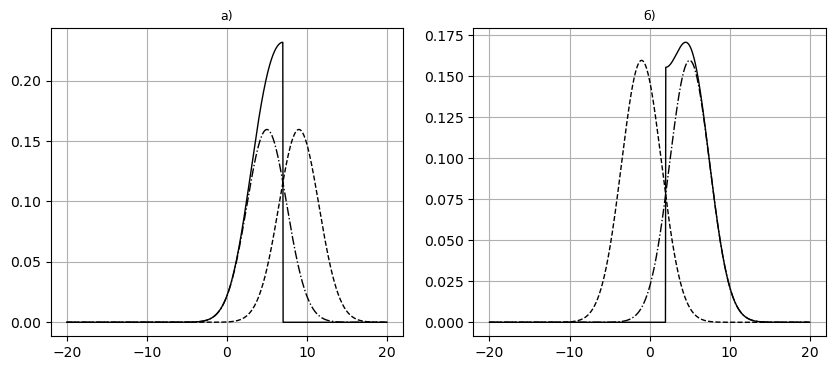

In [3]:
# Ячейка № 3

# задание параметров
# плотности распределения
# порождающего источника (x0, Sigma)
x0 = 5
Sigma = 2.5

# задание правой границы
# области рассеяния
X_max = 7

# задание левой границы
# области рассеяния
X_min = 2

# задание значений узлов
# координатной сетки
x = np.linspace(-20, 20, 1000)

# вычисление шага изменения координат узлов
dx = x[1] - x[0]

if x0 > X_max:
    print("Задайте X0, X_max, такими, что X0 < Xmax")
else:
    if x0 < X_min:
        print("Задайте X0, X_min, такими, что X0 > X_min")
    else:
        # вычисление плотностей распределений:
        # порождающего источника (Zn_R),
        # мнимого источника (Zim_R),
        # ограниченной справа случайной
        Z_N_R, Z_Im_R, Z_Lim_R = Pb_Lim(x, x0, Sigma, X_max)

        fig = plt.figure(figsize=(10, 4))
        # визуализация плотностей
        # распределений Zn_R, Zim_R, Zb_R
        ax = plt.subplot(1, 2, 1)
        ax.plot(x, Z_N_R, "-.k", lw=1)
        ax.plot(x, Z_Im_R, "--k", lw=1)
        ax.plot(x, Z_Lim_R, "-k", lw=1)
        ax.grid(True)
        ax.set_title("а)", fontsize=9)
        Z_N_L, Z_Im_L, Z_Lim_L = Pb_Lim(x, x0, Sigma, X_min)
        # визуализация плотностей
        # распределений Zn_L, Zim_L, Zb_L
        ax = plt.subplot(1, 2, 2)
        ax.plot(x, Z_N_L, "-.k", lw=1)
        ax.plot(x, Z_Im_L, "--k", lw=1)
        ax.plot(x, Z_Lim_L, "-k", lw=1)
        ax.grid(True)
        ax.set_title("б)", fontsize=9)

plt.show()

In [4]:
# Ячейка № 4

# вычисление параметров
# плотностей распределений
# распределения ограниченной справа
# случайной величины

# вычисление математических ожиданий
M_Z_N_R = np.trapz(x * Z_N_R, dx=dx)
M_Z_Im_R = np.trapz(x * Z_Im_R, dx=dx)
M_Z_Lim_R = np.trapz(x * Z_Lim_R, dx=dx)

# вычисление среднеквадратических_ отклонений
D_Z_N_R = np.sqrt(np.trapz((x - M_Z_N_R) ** 2 * Z_N_R, dx=dx))
D_Z_Im_R = np.sqrt(np.trapz((x - M_Z_Im_R) ** 2 * Z_Im_R, dx=dx))
D_Z_Lim_R = np.sqrt(np.trapz((x - M_Z_Lim_R) ** 2 * Z_Lim_R, dx=dx))

print("       РАСПРЕДЕЛЕНИЕ С ОГРАНИЧЕННОЙ СПРАВА ОБЛАСТЬЮ РАССЕЯНИЯ ", "\n")
print("1. ПАРАМЕТРЫ ПОРОЖДАЮЩЕГО РАСПРЕДЕЛЕНИЯ", "\n")
print(
    "Интеграл от плотности порождающего распределения: ", np.trapz(Z_N_R, dx=dx), "\n"
)
print("Математическое ожидание порождающего распределения: ", M_Z_N_R, "\n")
print("Дисперсия порождающего распределения: ", D_Z_N_R, "\n", "\n")

print("2. ПАРАМЕТРЫ МНИМОГО РАСПРЕДЕЛЕНИЯ", "\n")
print(
    "Интеграл от плотности вероятностей",
    "\n",
    "распределения мнимого источника: ",
    np.trapz(Z_Im_R, dx=dx),
    " \n",
)
print(
    "Математическое ожидание", "\n", "распределения мнимого источника: ", M_Z_Im_R, "\n"
)
print("Дисперсия мнимого распределения: ", D_Z_Im_R, "\n", "\n")

print("3. ПАРАМЕТРЫ ОГРАНИЧЕННОГО СПРАВА РАСПРЕДЕЛЕНИЯ ", "\n")
print(
    "Интеграл от ограниченного справа распределения: ", np.trapz(Z_Lim_R, dx=dx), "\n"
)
print(
    "Математическое ожидание",
    "\n",
    "ограниченного справа распределения: ",
    M_Z_Lim_R,
    "\n",
)
print("Дисперсия ограниченного справа распределения: ", D_Z_Lim_R, "\n")

       РАСПРЕДЕЛЕНИЕ С ОГРАНИЧЕННОЙ СПРАВА ОБЛАСТЬЮ РАССЕЯНИЯ  

1. ПАРАМЕТРЫ ПОРОЖДАЮЩЕГО РАСПРЕДЕЛЕНИЯ 

Интеграл от плотности порождающего распределения:  0.9999999990126327 

Математическое ожидание порождающего распределения:  4.999999979862093 

Дисперсия порождающего распределения:  2.4999999531645285 
 

2. ПАРАМЕТРЫ МНИМОГО РАСПРЕДЕЛЕНИЯ 

Интеграл от плотности вероятностей 
 распределения мнимого источника:  0.9999945851102997  

Математическое ожидание 
 распределения мнимого источника:  8.999888885343376 

Дисперсия мнимого распределения:  2.499855995372686 
 

3. ПАРАМЕТРЫ ОГРАНИЧЕННОГО СПРАВА РАСПРЕДЕЛЕНИЯ  

Интеграл от ограниченного справа распределения:  1.0016239020748516 

Математическое ожидание 
 ограниченного справа распределения:  4.4103213531511045 

Дисперсия ограниченного справа распределения:  1.8696468989623491 



In [5]:
# Ячейка № 5

# вычисление параметров
# плотностей распределений
# распределения ограниченной слева
# случайной величины

# вычисление математических ожиданий
M_Z_N_L = np.trapz(x * Z_N_L, dx=dx)
M_Z_Im_L = np.trapz(x * Z_Im_L, dx=dx)
M_Z_Lim_L = np.trapz(x * Z_Lim_L, dx=dx)

# вычисление дисперсий
D_Z_N_L = np.sqrt(np.trapz((x - M_Z_N_L) ** 2 * Z_N_L, dx=dx))
D_Z_Im_L = np.sqrt(np.trapz((x - M_Z_Im_L) ** 2 * Z_Im_L, dx=dx))
D_Z_Lim_L = np.sqrt(np.trapz((x - M_Z_Lim_L) ** 2 * Z_Im_L, dx=dx))

print("       РАСПРЕДЕЛЕНИЕ С ОГРАНИЧЕННОЙ СЛЕВА ОБЛАСТЬЮ РАССЕЯНИЯ ", "\n")
print("1. ПАРАМЕТРЫ ПОРОЖДАЮЩЕГО РАСПРЕДЕЛЕНИЯ", "\n")
print(
    "Интеграл от плотности порождающего распределения: ", np.trapz(Z_N_L, dx=dx), "\n"
)
print("Математическое ожидание порождающего распределения: ", M_Z_N_L, "\n")
print("Дисперсия порождающего распределения: ", D_Z_N_L, "\n", "\n")

print("2. ПАРАМЕТРЫ МНИМОГО РАСПРЕДЕЛЕНИЯ", "\n")
print(
    "Интеграл от плотности вероятностей",
    "\n",
    "распределения мнимого источника: ",
    np.trapz(Z_Lim_L, dx=dx),
    "\n",
)
print(
    "Математическое ожидание", "\n", "распределения мнимого источника: ", M_Z_Im_L, "\n"
)
print("Дисперсия мнимого распределения: ", D_Z_Im_L, "\n", "\n")

print("3. ПАРАМЕТРЫ ОГРАНИЧЕННОГО СПРАВА РАСПРЕДЕЛЕНИЯ ", "\n")
print("Интеграл от ограниченного слева распределения: ", np.trapz(Z_Lim_L, dx=dx), "\n")
print(
    "Математическое ожидание",
    "\n",
    "ограниченного слева распределения: ",
    M_Z_Lim_L,
    "\n",
)
print("Дисперсия ограниченного слева распределения: ", D_Z_Lim_L, "\n")

       РАСПРЕДЕЛЕНИЕ С ОГРАНИЧЕННОЙ СЛЕВА ОБЛАСТЬЮ РАССЕЯНИЯ  

1. ПАРАМЕТРЫ ПОРОЖДАЮЩЕГО РАСПРЕДЕЛЕНИЯ 

Интеграл от плотности порождающего распределения:  0.9999999990126327 

Математическое ожидание порождающего распределения:  4.999999979862093 

Дисперсия порождающего распределения:  2.4999999531645285 
 

2. ПАРАМЕТРЫ МНИМОГО РАСПРЕДЕЛЕНИЯ 

Интеграл от плотности вероятностей 
 распределения мнимого источника:  0.9996889917640157 

Математическое ожидание 
 распределения мнимого источника:  -0.999999999999699 

Дисперсия мнимого распределения:  2.4999999999988907 
 

3. ПАРАМЕТРЫ ОГРАНИЧЕННОГО СПРАВА РАСПРЕДЕЛЕНИЯ  

Интеграл от ограниченного слева распределения:  0.9996889917640157 

Математическое ожидание 
 ограниченного слева распределения:  5.279900284866425 

Дисперсия ограниченного слева распределения:  6.759226848379604 

